# This File is same with the main_pso but it uses mae instead of mse

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
#All the libraries used in the notebook
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from pyswarms.single import GlobalBestPSO
from skopt import gp_minimize
from skopt.space import Real
import plotly.express as px

In [ ]:
df = pd.read_csv("data/all_data_merged.csv", parse_dates=["DATE"])

df = df.sort_values(["DISTRICT","DATE"])

district_groups = {d: g.reset_index(drop=True)
                   for d, g in df.groupby("DISTRICT")}

print(f"Number of districts: {len(district_groups)}")
print(f"Districts: {list(district_groups.keys())}")
print(f"First district:\n{district_groups[1].head()}")
print("shape:", district_groups[1].shape)

Number of districts: 37
Districts: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]
First district:
        DATE  DISTRICT  WEATHER_CONDITION  SPECIAL_DAY  DAY_OF_WEEK_NUM  \
0 2024-01-01         1                  1            1                1   
1 2024-01-03         1                  2            0                3   
2 2024-01-04         1                  2            0                4   
3 2024-01-05         1                  2            0                5   
4 2024-01-06         1                  1            0                6   

   POPULATION  RAILWAY_STATIONS  BUS_STATIONS  CONGESTION  
0      344868                 5           678       0.213  
1      344868                 5           678       0.243  
2      344868                 5           678       0.234  
3      344868                 5           678       0.238  
4      344868                 5           678       0.246 

In [ ]:
def make_sequences(group, seq_len=10):
    X_raw = group[["WEATHER_CONDITION","SPECIAL_DAY","DAY_OF_WEEK_NUM",
                   "POPULATION","RAILWAY_STATIONS","BUS_STATIONS"]].values
    y_raw = group["CONGESTION"].values.reshape(-1,1)
    
    sx, sy = MinMaxScaler(), MinMaxScaler()
    Xs, ys = sx.fit_transform(X_raw), sy.fit_transform(y_raw)
    
    Xs_seq, ys_seq = [], []
    for i in range(len(Xs) - seq_len):
        Xs_seq.append(Xs[i:i+seq_len])
        ys_seq.append(ys[i+seq_len])
    return np.array(Xs_seq), np.array(ys_seq), sy

In [4]:
import torch
import torch.nn as nn

class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_dim=32, n_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_dim, n_layers, batch_first=True)
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h, _ = self.lstm(x)
        return self.out(h[:, -1, :])

In [5]:
def flatten_weights(model):
    return np.concatenate([p.detach().cpu().numpy().ravel() for p in model.parameters()])

def unflatten_weights(model, vec):
    idx = 0
    for p in model.parameters():
        numel = p.numel()
        chunk = vec[idx:idx+numel].reshape(p.shape)
        p.data.copy_(torch.from_numpy(chunk))
        idx += numel

In [ ]:
def make_fitness(X_train, y_train, device="cpu"):
    model = LSTMRegressor(n_features=X_train.shape[-1]).to(device)
    dim = sum(p.numel() for p in model.parameters())

    def fitness(pop):
        losses = []
        criterion = nn.L1Loss()
        Xb = torch.tensor(X_train, dtype=torch.float32).to(device)
        yb = torch.tensor(y_train, dtype=torch.float32).to(device)
        for particle in pop:
            unflatten_weights(model, particle)
            preds = model(Xb).squeeze()
            loss = criterion(preds, yb.squeeze()).item()
            losses.append(loss)
        return np.array(losses)

    return fitness, dim, model

In [7]:
import numpy as np

def pso_optimize(
    fitness_func,
    dim,
    n_particles=30,
    n_iters=100,
    w=0.9,
    c1=0.5,
    c2=0.3,
    bounds=None,
    verbose=True
):
    if bounds is not None:
        low, high = bounds
        pos = np.random.uniform(low, high, (n_particles, dim))
    else:
        pos = np.random.randn(n_particles, dim) * 0.1
    vel = np.zeros_like(pos)

    fitness = fitness_func(pos)
    pbest_pos   = pos.copy()
    pbest_score = fitness.copy()
    gbest_idx   = np.argmin(pbest_score)
    gbest_pos   = pbest_pos[gbest_idx].copy()
    gbest_score = pbest_score[gbest_idx]

    for it in range(1, n_iters+1):
        r1 = np.random.rand(n_particles, dim)
        r2 = np.random.rand(n_particles, dim)

        vel = (
            w * vel
            + c1 * r1 * (pbest_pos - pos)
            + c2 * r2 * (gbest_pos - pos)
        )

        pos = pos + vel

        if bounds is not None:
            pos = np.clip(pos, low, high)

        fitness = fitness_func(pos)

        better_mask = fitness < pbest_score
        pbest_pos[better_mask]   = pos[better_mask]
        pbest_score[better_mask] = fitness[better_mask]

        current_best_idx = np.argmin(pbest_score)
        if pbest_score[current_best_idx] < gbest_score:
            gbest_score = pbest_score[current_best_idx]
            gbest_pos   = pbest_pos[current_best_idx].copy()

        if verbose and it % 10 == 0:
            print(f"Iter {it:3d}/{n_iters},  gbest MAE = {gbest_score:.6f}")

    return gbest_score, gbest_pos

In [ ]:
def flatten_gradients(model):
    return np.concatenate([
        p.grad.detach().cpu().numpy().ravel()
        for p in model.parameters()
    ])

def hybrid_pso_optimize(
    model,
    X_train, y_train,
    dim,
    n_particles=30,
    n_iters=100,
    w=0.9,
    c1=0.5,
    c2=0.3,
    alpha=0.01,
    bounds=None,
    verbose=True
):
    criterion = nn.L1Loss()

    if bounds is not None:
        low, high = bounds
        pos = np.random.uniform(low, high, (n_particles, dim))
    else:
        pos = np.random.randn(n_particles, dim)*0.1
    vel = np.zeros_like(pos)

    def eval_fitness(pop):
        out = []
        for p in pop:
            unflatten_weights(model, p)
            with torch.no_grad():
                preds = model(X_train).squeeze()
            loss = criterion(preds, y_train.squeeze()).item()
            out.append(loss)
        return np.array(out)

    fitness = eval_fitness(pos)
    pbest_pos   = pos.copy()
    pbest_score = fitness.copy()
    gidx        = np.argmin(pbest_score)
    gbest_pos   = pbest_pos[gidx].copy()
    gbest_score = pbest_score[gidx]

    for it in range(1, n_iters+1):
        r1 = np.random.rand(n_particles, dim)
        r2 = np.random.rand(n_particles, dim)

        grads = []
        for p in pos:
            unflatten_weights(model, p)
            model.zero_grad()
            preds = model(X_train).squeeze()
            loss  = criterion(preds, y_train.squeeze())
            loss.backward()
            grads.append(flatten_gradients(model))
        grads = np.array(grads)

        vel = (
            w * vel
            + c1 * r1 * (pbest_pos - pos)
            + c2 * r2 * (gbest_pos - pos)
            - alpha * grads
        )

        pos = pos + vel
        if bounds is not None:
            pos = np.clip(pos, low, high)

        fitness = eval_fitness(pos)

        better = fitness < pbest_score
        pbest_pos[better]   = pos[better]
        pbest_score[better] = fitness[better]

        idx = np.argmin(pbest_score)
        if pbest_score[idx] < gbest_score:
            gbest_score = pbest_score[idx]
            gbest_pos   = pbest_pos[idx].copy()

        if verbose and it % 10 == 0:
            print(f"Iter {it:3d}/{n_iters}, gbest MAE = {gbest_score:.6f}")

    return gbest_score, gbest_pos

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_splits = []
test_splits  = {}
for d, group in district_groups.items():
    X, y, scaler = make_sequences(group, seq_len=10)
    split_idx   = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    train_splits.append((X_train, y_train))
    test_splits[d] = (X_test, y_test, scaler)

X_train_all = np.concatenate([tr[0] for tr in train_splits], axis=0)
y_train_all = np.concatenate([tr[1] for tr in train_splits], axis=0)

Xb_train = torch.tensor(X_train_all, dtype=torch.float32, device=device)
yb_train = torch.tensor(y_train_all, dtype=torch.float32, device=device)

model = LSTMRegressor(n_features=X_train_all.shape[-1]).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
dim   = total_params

start_time = time.time()

best_cost, best_pos = hybrid_pso_optimize(
    model, Xb_train, yb_train, dim,
    n_particles=30,
    n_iters=100,
    w=0.9, c1=0.5, c2=0.3, alpha=0.01,
    bounds=(-1,1),
    verbose=True
)
unflatten_weights(model, best_pos)

end_time = time.time()
elapsed = end_time - start_time
print(f"Training completed in {elapsed:.3f} seconds")

results_hybrid = {}
model.eval()
with torch.no_grad():
    for d, (X_test, y_test, scaler) in test_splits.items():
        Xb_test = torch.tensor(X_test, dtype=torch.float32, device=device)
        y_pred_scaled = model(Xb_test).cpu().numpy()
        
        y_pred = scaler.inverse_transform(y_pred_scaled)
        y_true = scaler.inverse_transform(y_test)
        test_mae = np.abs(y_pred - y_true).mean()

        results_hybrid[d] = {
            "model": model,
            "scaler": scaler,
            "train_mae": best_cost,
            "test_mae": test_mae
        }
        print(f"District {d}: test MAE = {test_mae:.4f}")

Total parameters: 5153
Iter  10/100, gbest MAE = 0.137410
Iter  20/100, gbest MAE = 0.125705
Iter  30/100, gbest MAE = 0.125705
Iter  40/100, gbest MAE = 0.122523
Iter  50/100, gbest MAE = 0.121552
Iter  60/100, gbest MAE = 0.120424
Iter  70/100, gbest MAE = 0.120099
Iter  80/100, gbest MAE = 0.118936
Iter  90/100, gbest MAE = 0.118505
Iter 100/100, gbest MAE = 0.118323
Training completed in 464.939 seconds
District 1: test MAE = 0.0274
District 2: test MAE = 0.0360
District 3: test MAE = 0.0532
District 4: test MAE = 0.0630
District 5: test MAE = 0.0530
District 6: test MAE = 0.0319
District 7: test MAE = 0.0350
District 8: test MAE = 0.0457
District 9: test MAE = 0.0363
District 10: test MAE = 0.0323
District 11: test MAE = 0.0396
District 12: test MAE = 0.0297
District 13: test MAE = 0.0371
District 15: test MAE = 0.0472
District 16: test MAE = 0.0539
District 17: test MAE = 0.0320
District 18: test MAE = 0.0405
District 19: test MAE = 0.0278
District 20: test MAE = 0.0373
District 

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_splits = []
test_splits  = {}
for d, group in district_groups.items():
    X, y, scaler = make_sequences(group, seq_len=10)
    split_idx   = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    train_splits.append((X_train, y_train))
    test_splits[d] = (X_test, y_test, scaler)

X_train_all = np.concatenate([tr[0] for tr in train_splits], axis=0)
y_train_all = np.concatenate([tr[1] for tr in train_splits], axis=0)

Xb_train = torch.tensor(X_train_all, dtype=torch.float32).to(device)
yb_train = torch.tensor(y_train_all, dtype=torch.float32).to(device)

from pyswarms.single import GlobalBestPSO

fitness, dim, model = make_fitness(X_train_all, y_train_all, device=device)
print(f"Total parameters to optimize: {dim}")

options = {
    'w': 0.9,
    'c1': 0.5,
    'c2': 0.3
}
bounds = (np.ones(dim)*-1, np.ones(dim)*1)

optimizer = GlobalBestPSO(
    n_particles=30,
    dimensions=dim,
    options=options,
    bounds=bounds
)

start_time = time.time()
best_cost, best_pos = optimizer.optimize(
    fitness, iters=100, verbose=True
)
end_time = time.time()

print(f"PSO training completed in {end_time - start_time:.2f} seconds")
unflatten_weights(model, best_pos)

results_grad_free_pso = {}
model.eval()
with torch.no_grad():
    for d, (X_test, y_test, scaler) in test_splits.items():
        Xb_test = torch.tensor(X_test, dtype=torch.float32).to(device)
        y_pred_scaled = model(Xb_test).cpu().numpy()
        
        y_pred = scaler.inverse_transform(y_pred_scaled)
        y_true = scaler.inverse_transform(y_test)
        test_mae = np.abs(y_pred - y_true).mean()

        results_grad_free_pso[d] = {
            "model": model,
            "scaler": scaler,
            "train_mae": best_cost,
            "test_mae": test_mae
        }
        print(f"District {d}: test MAE = {test_mae:.4f}")

Total parameters to optimize: 5153


2025-05-26 15:24:03,348 - pyswarms.single.global_best - INFO - Optimize for 100 iters with {'w': 0.9, 'c1': 0.5, 'c2': 0.3}
pyswarms.single.global_best: 100%|██████████|100/100, best_cost=0.133
2025-05-26 15:25:49,604 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.13275539875030518, best pos: [-0.16434548  0.38497882 -0.09078926 ... -0.52663577 -0.07084112
  0.44327921]


PSO training completed in 106.26 seconds
District 1: test MAE = 0.0228
District 2: test MAE = 0.0388
District 3: test MAE = 0.0635
District 4: test MAE = 0.0782
District 5: test MAE = 0.0623
District 6: test MAE = 0.0308
District 7: test MAE = 0.0438
District 8: test MAE = 0.0497
District 9: test MAE = 0.0359
District 10: test MAE = 0.0290
District 11: test MAE = 0.0408
District 12: test MAE = 0.0357
District 13: test MAE = 0.0347
District 15: test MAE = 0.0410
District 16: test MAE = 0.0534
District 17: test MAE = 0.0278
District 18: test MAE = 0.0358
District 19: test MAE = 0.0319
District 20: test MAE = 0.0328
District 21: test MAE = 0.0278
District 22: test MAE = 0.0490
District 23: test MAE = 0.0336
District 24: test MAE = 0.0307
District 25: test MAE = 0.0259
District 26: test MAE = 0.0380
District 27: test MAE = 0.0471
District 28: test MAE = 0.0256
District 29: test MAE = 0.0363
District 30: test MAE = 0.0424
District 31: test MAE = 0.0440
District 32: test MAE = 0.0292
Distric

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_splits = []
test_splits  = {}
for d, group in district_groups.items():
    X, y, scaler = make_sequences(group, seq_len=10)
    split_idx   = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    train_splits.append((X_train, y_train))
    test_splits[d] = (X_test, y_test, scaler)

X_train_all = np.concatenate([tr[0] for tr in train_splits], axis=0)
y_train_all = np.concatenate([tr[1] for tr in train_splits], axis=0)

Xb_train = torch.tensor(X_train_all, dtype=torch.float32).to(device)
yb_train = torch.tensor(y_train_all, dtype=torch.float32).to(device)

fitness, dim, model = make_fitness(X_train_all, y_train_all, device=device)
print(f"Total parameters to optimize: {dim}")
model = LSTMRegressor(n_features=X_train_all.shape[-1]).to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.L1Loss()

n_epochs = 100
start_time = time.time()

for epoch in range(1, n_epochs+1):
    model.train()
    optimizer.zero_grad()
    
    preds = model(Xb_train).squeeze()
    loss  = criterion(preds, yb_train.squeeze())
    
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{n_epochs} — train loss: {loss.item():.6f}")

elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.2f} sec")


results_adam = {}
model.eval()
with torch.no_grad():
    for d, (X_test, y_test, scaler) in test_splits.items():
        Xb_test = torch.tensor(X_test, dtype=torch.float32, device=device)
        y_pred_scaled = model(Xb_test).cpu().numpy()
        
        y_pred = scaler.inverse_transform(y_pred_scaled)
        y_true = scaler.inverse_transform(y_test)
        test_mae = np.abs(y_pred - y_true).mean()
        
        print(f"District {d}: test MAE = {test_mae:.4f}")
        results_adam[d] = {
            "model": model,
            "scaler": scaler,
            "train_mae": loss.item(),
            "test_mae": test_mae
        }

Total parameters to optimize: 5153
Total parameters: 5153
Epoch   1/100 — train loss: 0.635120
Epoch  10/100 — train loss: 0.542671
Epoch  20/100 — train loss: 0.410630
Epoch  30/100 — train loss: 0.195709
Epoch  40/100 — train loss: 0.164650
Epoch  50/100 — train loss: 0.152882
Epoch  60/100 — train loss: 0.141640
Epoch  70/100 — train loss: 0.139998
Epoch  80/100 — train loss: 0.139015
Epoch  90/100 — train loss: 0.137645
Epoch 100/100 — train loss: 0.136371
Training completed in 15.36 sec
District 1: test MAE = 0.0357
District 2: test MAE = 0.0427
District 3: test MAE = 0.0514
District 4: test MAE = 0.0562
District 5: test MAE = 0.0522
District 6: test MAE = 0.0417
District 7: test MAE = 0.0369
District 8: test MAE = 0.0561
District 9: test MAE = 0.0487
District 10: test MAE = 0.0416
District 11: test MAE = 0.0489
District 12: test MAE = 0.0365
District 13: test MAE = 0.0432
District 15: test MAE = 0.0587
District 16: test MAE = 0.0676
District 17: test MAE = 0.0448
District 18: tes

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_splits = []
test_splits  = {}
for d, group in district_groups.items():
    X, y, scaler = make_sequences(group, seq_len=10)
    split_idx     = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    train_splits.append((X_train, y_train))
    test_splits[d] = (X_test, y_test, scaler)

X_train_all = np.concatenate([tr[0] for tr in train_splits], axis=0)
y_train_all = np.concatenate([tr[1] for tr in train_splits], axis=0)

Xb_train = torch.tensor(X_train_all, dtype=torch.float32, device=device)

model = LSTMRegressor(n_features=X_train_all.shape[-1]).to(device)
dim   = sum(p.numel() for p in model.parameters())
print(f"Total parameters to optimize: {dim}")

def objective(weights):
    w_flat = np.array(weights)
    unflatten_weights(model, w_flat)
    model.eval()
    with torch.no_grad():
        preds = model(Xb_train).cpu().numpy().flatten()
    return np.abs(preds - y_train_all).mean()

space = [Real(-1, 1) for _ in range(dim)]
start_time = time.time()
result = gp_minimize(
    func=objective,
    dimensions=space,
    acq_func="EI",
    n_calls=20,
    random_state=42
)
elapsed = time.time() - start_time

best_weights = np.array(result.x)
best_cost    = result.fun
unflatten_weights(model, best_weights)

print(f"Bayesian optimization completed in {elapsed:.2f} seconds")
print(f"Best training MAE: {best_cost:.6f}")

results_bayes = {}
model.eval()
with torch.no_grad():
    for d, (X_test, y_test, scaler) in test_splits.items():
        Xb_test = torch.tensor(X_test, dtype=torch.float32, device=device)
        y_pred_scaled = model(Xb_test).cpu().numpy()
        y_pred = scaler.inverse_transform(y_pred_scaled)
        y_true = scaler.inverse_transform(y_test)
        test_mae = np.abs(y_pred - y_true).mean()

        results_bayes[d] = {
            "model": model,
            "scaler": scaler,
            "train_mae": best_cost,
            "test_mae": test_mae
        }
        print(f"District {d}: test MAE = {test_mae:.4f}")


Total parameters to optimize: 5153
Bayesian optimization completed in 402.96 seconds
Best training MAE: 0.320285
District 1: test MAE = 0.1191
District 2: test MAE = 0.1472
District 3: test MAE = 0.1623
District 4: test MAE = 0.1940
District 5: test MAE = 0.1630
District 6: test MAE = 0.1185
District 7: test MAE = 0.1631
District 8: test MAE = 0.1933
District 9: test MAE = 0.1558
District 10: test MAE = 0.1155
District 11: test MAE = 0.1475
District 12: test MAE = 0.1617
District 13: test MAE = 0.0833
District 15: test MAE = 0.1666
District 16: test MAE = 0.1990
District 17: test MAE = 0.1893
District 18: test MAE = 0.1330
District 19: test MAE = 0.1598
District 20: test MAE = 0.1359
District 21: test MAE = 0.1086
District 22: test MAE = 0.1497
District 23: test MAE = 0.1458
District 24: test MAE = 0.1241
District 25: test MAE = 0.0920
District 26: test MAE = 0.1587
District 27: test MAE = 0.1551
District 28: test MAE = 0.0915
District 29: test MAE = 0.1013
District 30: test MAE = 0.16

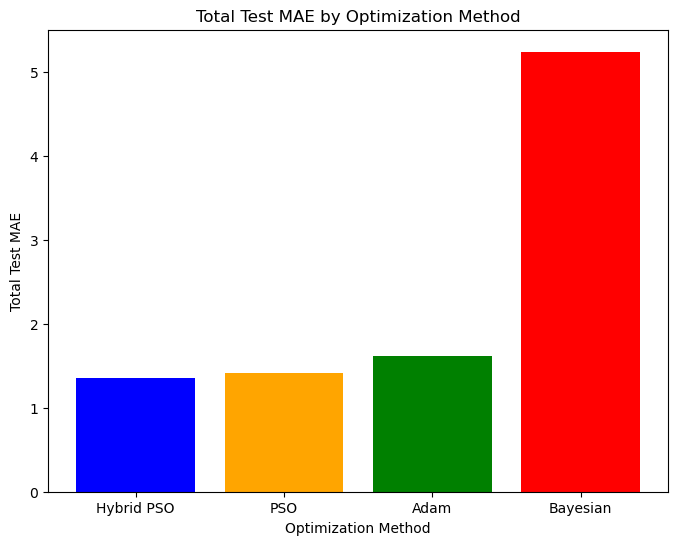

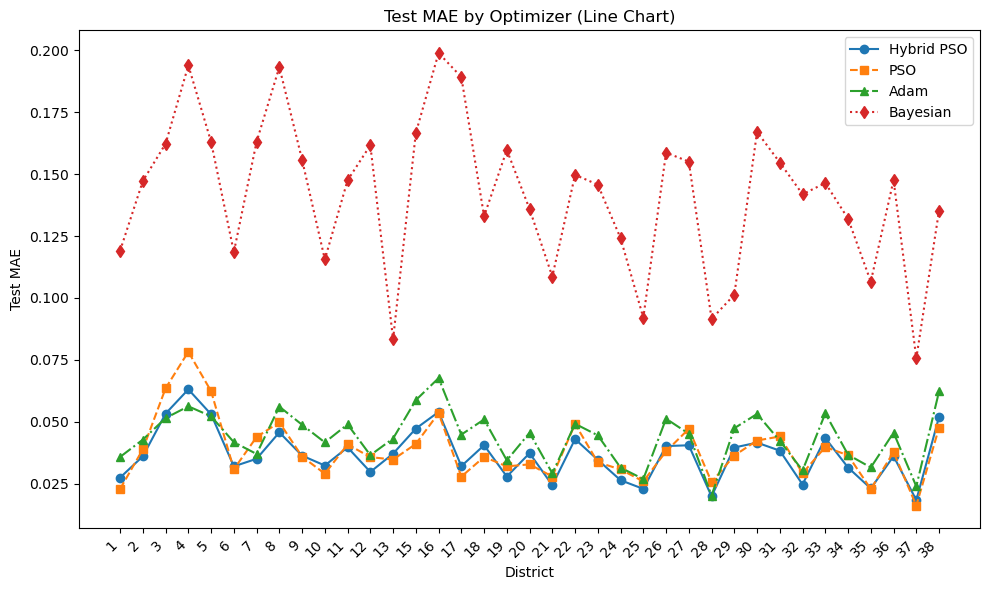

In [ ]:
districts = list(results_hybrid.keys())
test_hybrid = [results_hybrid[d]['test_mae'] for d in districts]
test_pso    = [results_grad_free_pso[d]['test_mae'] for d in districts]
test_adam   = [results_adam[d]['test_mae'] for d in districts]
test_bayes  = [results_bayes[d]['test_mae'] for d in districts]

total_hybrid = sum(test_hybrid)
total_pso = sum(test_pso)
total_adam = sum(test_adam)
total_bayes = sum(test_bayes)

methods = ['Hybrid PSO', 'PSO', 'Adam', 'Bayesian']
totals = [total_hybrid, total_pso, total_adam, total_bayes]

plt.figure(figsize=(8, 6))
plt.bar(methods, totals, color=['blue', 'orange', 'green', 'red'])
plt.xlabel('Optimization Method')
plt.ylabel('Total Test MAE')
plt.title('Total Test MAE by Optimization Method')
plt.show()


x = np.arange(len(districts))

plt.figure(figsize=(10, 6))
plt.plot(x, test_hybrid, marker='o', linestyle='-', label='Hybrid PSO')
plt.plot(x, test_pso,    marker='s', linestyle='--', label='PSO')
plt.plot(x, test_adam,   marker='^', linestyle='-.', label='Adam')
plt.plot(x, test_bayes,  marker='d', linestyle=':', label='Bayesian')

plt.xticks(x, districts, rotation=45, ha='right')
plt.xlabel('District')
plt.ylabel('Test MAE')
plt.title('Test MAE by Optimizer (Line Chart)')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
def resultsdict_to_df(result_dict, method_name):
    df = pd.DataFrame([
        {
            "District": k,
            "train_mae": v['train_mae'],
            "test_mae": v['test_mae'],
            "method": method_name
        }
        for k, v in result_dict.items()
    ])
    return df

df_pso = resultsdict_to_df(results_grad_free_pso, "PSO")
df_adam = resultsdict_to_df(results_adam, "Adam")
df_bayes = resultsdict_to_df(results_bayes, "Bayesian")
df_hybrid = resultsdict_to_df(results_hybrid, "Hybrid")

In [15]:
df_all = pd.concat([df_pso, df_adam, df_bayes, df_hybrid], ignore_index=True)

In [16]:
display(df_all.pivot_table(index="District", columns="method", values="test_mae")
    .style.background_gradient(cmap="YlOrBr").set_caption("Test MAE per District/Method"))

method,Adam,Bayesian,Hybrid,PSO
District,,,,
1,0.035746,0.119072,0.027390,0.022805
2,0.042740,0.147247,0.036009,0.038821
3,0.051446,0.162308,0.053247,0.063482
4,0.056203,0.193951,0.063048,0.078242
5,0.052151,0.163038,0.052964,0.062301
6,0.041701,0.118496,0.031944,0.030763
7,0.036936,0.163088,0.034985,0.043799
8,0.056079,0.193277,0.045681,0.049729
9,0.048743,0.155818,0.036267,0.035874


2025-05-26 15:32:56,884 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-26 15:32:56,892 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


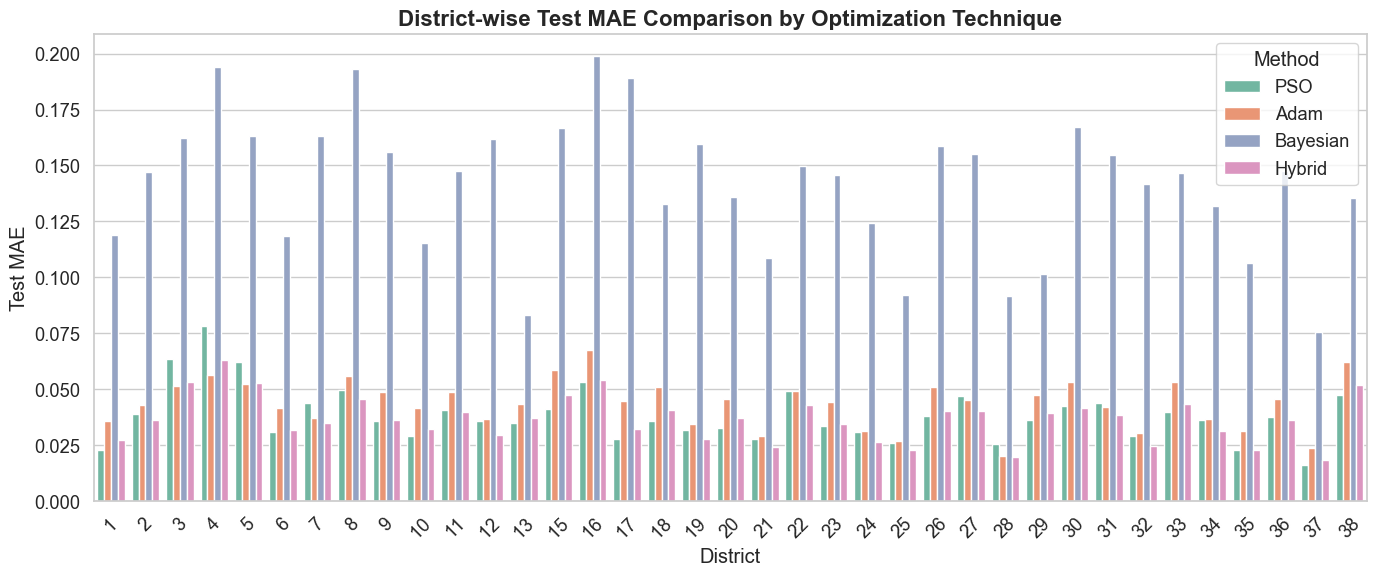

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(14,6))
sns.barplot(data=df_all, x="District", y="test_mae", hue="method", palette="Set2")
plt.title("District-wise Test MAE Comparison by Optimization Technique", fontsize=16, weight="bold")
plt.ylabel("Test MAE")
plt.xlabel("District")
plt.xticks(rotation=45)
plt.legend(title="Method")
plt.tight_layout()
plt.show()

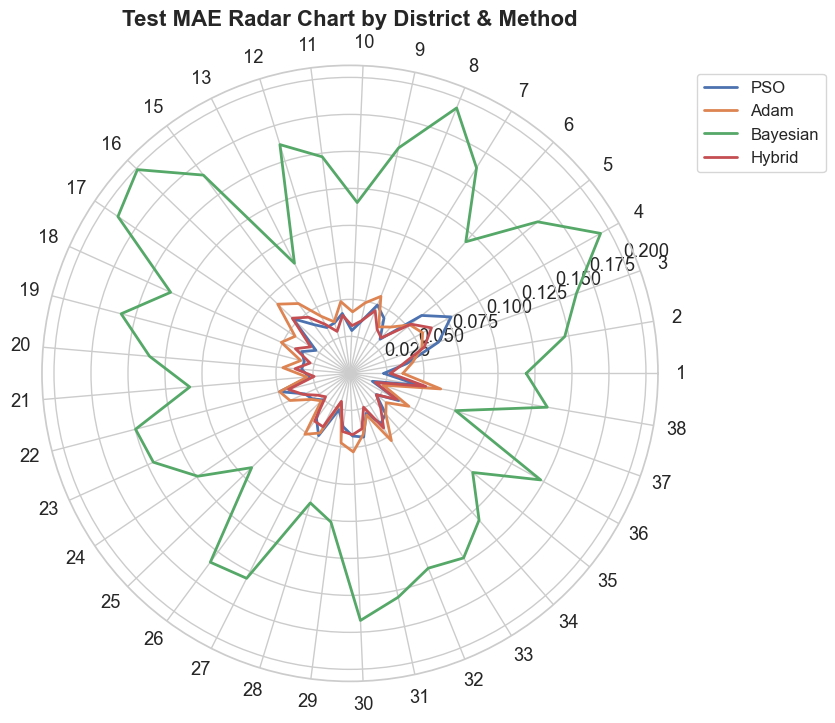

In [18]:
districts = sorted(df_all["District"].unique())
methods = df_all["method"].unique()

plt.figure(figsize=(8,8))
angles = np.linspace(0, 2 * np.pi, len(districts), endpoint=False).tolist()
angles += angles[:1]

for method in methods:
    stats = df_all[df_all["method"] == method].sort_values("District")["test_mae"].tolist()
    stats += stats[:1]
    plt.polar(angles, stats, label=method, linewidth=2)

plt.xticks(angles[:-1], districts)
plt.title("Test MAE Radar Chart by District & Method", fontsize=16, weight="bold")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12)
plt.show()

In [ ]:
fig = px.parallel_coordinates(df_all, color="test_mae",
                              dimensions=["District", "method", "test_mae"],
                              color_continuous_scale=px.colors.diverging.Tealrose)
fig.update_layout(title="Parallel Coordinates: Test MAE Across Methods & Districts")
fig.show()

In [20]:
districts = sorted(df_all["District"].unique())

fig = px.bar(
    df_all,
    x="method",
    y="test_mae",
    color="method",
    animation_frame="District",
    animation_group="method",
    range_y=[df_all['test_mae'].min()*0.9, df_all['test_mae'].max()*1.05],
    labels={"test_mae": "Test MAE"},
    title="District-wise Optimization Method Comparison (Animated)",
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(xaxis_title="Method", yaxis_title="Test MAE", showlegend=False)
fig.show()